In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
claims = pd.read_csv("C:/Users/HP/Desktop/Downloads/claims_data.csv")

In [4]:
claims.head()

,Claim_ID,Food_ID,Receiver_ID,Status,Timestamp
0,1,164,908,Pending,3/5/2025 5:26
1,2,353,391,Cancelled,3/11/2025 10:24
2,3,626,492,Completed,3/21/2025 0:59
3,4,61,933,Cancelled,3/4/2025 9:08
4,5,345,229,Pending,3/14/2025 15:17


In [5]:
claims.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Claim_ID     1000 non-null   int64 
 1   Food_ID      1000 non-null   int64 
 2   Receiver_ID  1000 non-null   int64 
 3   Status       1000 non-null   object
 4   Timestamp    1000 non-null   object
dtypes: int64(3), object(2)
memory usage: 39.2+ KB


In [6]:
claims.duplicated().sum()

np.int64(0)

In [7]:
claims['Status'].value_counts()

Status
Completed    339
Cancelled    336
Pending      325
Name: count, dtype: int64

In [8]:
claims['Timestamp'] = pd.to_datetime(claims['Timestamp'])

In [9]:
claims.head()

,Claim_ID,Food_ID,Receiver_ID,Status,Timestamp
0,1,164,908,Pending,2025-03-05 05:26:00
1,2,353,391,Cancelled,2025-03-11 10:24:00
2,3,626,492,Completed,2025-03-21 00:59:00
3,4,61,933,Cancelled,2025-03-04 09:08:00
4,5,345,229,Pending,2025-03-14 15:17:00


STATUS PERCENTAGE

In [10]:
(claims['Status'].value_counts(normalize=True)*100).round(2)

Status
Completed    33.9
Cancelled    33.6
Pending      32.5
Name: proportion, dtype: float64

CLAIMS BY MONTH

In [11]:
claims.groupby(claims['Timestamp'].dt.month).size()

Timestamp
3    1000
dtype: int64

CLAIMS BY DAY

In [12]:
claims.groupby(claims['Timestamp'].dt.day_name()).size()

Timestamp
Friday       123
Monday       160
Saturday     147
Sunday       132
Thursday     144
Tuesday      145
Wednesday    149
dtype: int64

In [13]:
claims.describe()

,Claim_ID,Food_ID,Receiver_ID,Timestamp
count,1000.000000,1000.000000,1000.000000,1000
mean,500.500000,502.163000,492.437000,2025-03-11 11:20:59.400000
min,1.000000,1.000000,1.000000,2025-03-01 00:09:00
25%,250.750000,233.750000,256.000000,2025-03-06 17:42:15
50%,500.500000,504.500000,480.500000,2025-03-11 16:08:00
75%,750.250000,762.000000,742.250000,2025-03-16 09:29:45
max,1000.000000,999.000000,1000.000000,2025-03-21 06:12:00
std,288.819436,292.462255,284.487869,NaN


In [14]:
claims['Claim_ID'].nunique()

1000

FOOD LISTINGS DATA

In [15]:
food = pd.read_csv("C:/Users/HP/Desktop/Downloads/food_listings_data.csv")

In [16]:
food.head()

,Food_ID,Food_Name,Quantity,Expiry_Date,Provider_ID,Provider_Type,Location,Food_Type,Meal_Type
0,1,Bread,43,3/17/2025,110,Grocery Store,South Kellyville,Non-Vegetarian,Breakfast
1,2,Soup,22,3/24/2025,791,Grocery Store,West James,Non-Vegetarian,Dinner
2,3,Fruits,46,3/28/2025,478,Catering Service,Lake Regina,Vegan,Breakfast
3,4,Fruits,15,3/16/2025,930,Restaurant,Kellytown,Vegan,Lunch
4,5,Soup,14,3/19/2025,279,Restaurant,Garciaport,Vegan,Dinner


In [17]:
food.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Food_ID        1000 non-null   int64 
 1   Food_Name      1000 non-null   object
 2   Quantity       1000 non-null   int64 
 3   Expiry_Date    1000 non-null   object
 4   Provider_ID    1000 non-null   int64 
 5   Provider_Type  1000 non-null   object
 6   Location       1000 non-null   object
 7   Food_Type      1000 non-null   object
 8   Meal_Type      1000 non-null   object
dtypes: int64(3), object(6)
memory usage: 70.4+ KB


In [18]:
food.isnull().sum()

Food_ID          0
Food_Name        0
Quantity         0
Expiry_Date      0
Provider_ID      0
Provider_Type    0
Location         0
Food_Type        0
Meal_Type        0
dtype: int64

In [19]:
food.duplicated().sum()

np.int64(0)

In [20]:
food['Food_ID'].nunique()

1000

In [21]:
food['Expiry_Date'] = pd.to_datetime(food['Expiry_Date'])

In [22]:
food.head()

,Food_ID,Food_Name,Quantity,Expiry_Date,Provider_ID,Provider_Type,Location,Food_Type,Meal_Type
0,1,Bread,43,2025-03-17,110,Grocery Store,South Kellyville,Non-Vegetarian,Breakfast
1,2,Soup,22,2025-03-24,791,Grocery Store,West James,Non-Vegetarian,Dinner
2,3,Fruits,46,2025-03-28,478,Catering Service,Lake Regina,Vegan,Breakfast
3,4,Fruits,15,2025-03-16,930,Restaurant,Kellytown,Vegan,Lunch
4,5,Soup,14,2025-03-19,279,Restaurant,Garciaport,Vegan,Dinner


In [23]:
food['Quantity'].describe()


count    1000.000000
mean       25.794000
std        14.609894
min         1.000000
25%        13.000000
50%        26.000000
75%        39.000000
max        50.000000
Name: Quantity, dtype: float64

In [24]:
food[food['Quantity'] <= 0]

,Food_ID,Food_Name,Quantity,Expiry_Date,Provider_ID,Provider_Type,Location,Food_Type,Meal_Type


In [25]:
food['Provider_Type'].value_counts()

Provider_Type
Supermarket         267
Restaurant          258
Grocery Store       243
Catering Service    232
Name: count, dtype: int64

In [26]:
food['Food_Type'].value_counts()

Food_Type
Vegetarian        336
Vegan             334
Non-Vegetarian    330
Name: count, dtype: int64

In [27]:
food['Meal_Type'].value_counts()

Meal_Type
Breakfast    254
Snacks       253
Lunch        248
Dinner       245
Name: count, dtype: int64

In [28]:
food['Location'].nunique()

624

PROVIDERS DATA

In [29]:
providers = pd.read_csv("C:/Users/HP/Desktop/Downloads/providers_data.csv")

In [30]:
providers.head()

,Provider_ID,Name,Type,Address,City,Contact
0,1,Gonzales-Cochran,Supermarket,"74347 Christopher Extensions\nAndreamouth, OK ...",New Jessica,+1-600-220-0480
1,2,"Nielsen, Johnson and Fuller",Grocery Store,"91228 Hanson Stream\nWelchtown, OR 27136",East Sheena,+1-925-283-8901x6297
2,3,Miller-Black,Supermarket,"561 Martinez Point Suite 507\nGuzmanchester, W...",Lake Jesusview,001-517-295-2206
3,4,"Clark, Prince and Williams",Grocery Store,"467 Bell Trail Suite 409\nPort Jesus, IA 61188",Mendezmouth,556.944.8935x401
4,5,Coleman-Farley,Grocery Store,"078 Matthew Creek Apt. 319\nSaraborough, MA 53978",Valentineside,193.714.6577


In [31]:
providers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Provider_ID  1000 non-null   int64 
 1   Name         1000 non-null   object
 2   Type         1000 non-null   object
 3   Address      1000 non-null   object
 4   City         1000 non-null   object
 5   Contact      1000 non-null   object
dtypes: int64(1), object(5)
memory usage: 47.0+ KB


In [32]:
providers.isnull().sum()

Provider_ID    0
Name           0
Type           0
Address        0
City           0
Contact        0
dtype: int64

In [33]:
providers.duplicated().sum()

np.int64(0)

In [34]:
providers['Provider_ID'].nunique()

1000

In [35]:
providers['Type'].value_counts()

Type
Supermarket         262
Grocery Store       256
Restaurant          246
Catering Service    236
Name: count, dtype: int64

In [36]:
providers['City'].nunique()

963

In [37]:
providers['Name'].duplicated().sum()

np.int64(27)

In [38]:
providers[providers['Name'].duplicated(keep=False)].sort_values('Name')

,Provider_ID,Name,Type,Address,City,Contact
910,911,Alexander PLC,Restaurant,"28329 Gary Courts\nEast Jonathan, KS 04105",Garciatown,599-601-7460
396,397,Alexander PLC,Catering Service,"467 Heather Trail Apt. 416\nSmithstad, SD 08586",Arnoldmouth,347-730-0183x269
197,198,Bowman LLC,Restaurant,"70033 Katie Walk\nSouth Joshuaport, NY 57110",Port Karen,(890)877-4218x852
354,355,Bowman LLC,Restaurant,"64024 Hunter Plaza Apt. 997\nGrantstad, NM 06478",Port Patrick,039-263-2786x611
397,398,Brown LLC,Supermarket,"013 Cook Spring\nBradleyborough, CA 82476",Jasminechester,(155)397-5919x994
596,597,Brown LLC,Supermarket,"8055 Angela Shoals\nJoshuamouth, FL 70099",Karentown,2169420064
187,188,Brown Ltd,Catering Service,"3165 Luis Heights\nPort Brandonview, OK 04929",Courtneychester,9776174564
458,459,Brown Ltd,Supermarket,"8358 Randy Mission\nMarkmouth, SC 03456",Castilloport,164.699.6716
435,436,Brown and Sons,Restaurant,"87132 Holland Hollow\nMirandamouth, IA 28722",North Christina,200.655.1498x63749
15,16,Brown and Sons,Catering Service,"1745 Chan Ridges\nGinaville, OK 07163",West Vanessafort,018-471-0550x16593


In [39]:
providers.groupby('Name').size().sort_values(ascending=False).head(10)

Name
Brown and Sons    4
Miller Inc        3
Miller Ltd        3
Smith Inc         3
Williams PLC      3
Campbell LLC      2
Lee LLC           2
Jackson LLC       2
Bowman LLC        2
Jackson Ltd       2
dtype: int64

In [40]:
providers[providers['Name'] == 'Brown and Sons']

,Provider_ID,Name,Type,Address,City,Contact
15,16,Brown and Sons,Catering Service,"1745 Chan Ridges\nGinaville, OK 07163",West Vanessafort,018-471-0550x16593
435,436,Brown and Sons,Restaurant,"87132 Holland Hollow\nMirandamouth, IA 28722",North Christina,200.655.1498x63749
648,649,Brown and Sons,Restaurant,"962 Carla Villages Suite 460\nNorth Johnstad, ...",Lake Benjamin,001-124-313-6789x492
848,849,Brown and Sons,Supermarket,"725 Garner Locks\nAndrewchester, MI 49979",South Christopherborough,(352)481-4738


RECEIVERS DATA

In [41]:
receivers = pd.read_csv("C:/Users/HP/Desktop/Downloads/receivers_data.csv")

In [42]:
receivers.head()

,Receiver_ID,Name,Type,City,Contact
0,1,Donald Gomez,Shelter,Port Carlburgh,(955)922-5295
1,2,Laurie Ramos,Individual,Lewisburgh,761.042.1570
2,3,Ashley Mckee,NGO,South Randalltown,691-023-0094x856
3,4,Erika Rose,NGO,South Shaneville,8296491111
4,5,John Romero,Individual,Bakerport,067.491.0154


In [43]:
receivers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Receiver_ID  1000 non-null   int64 
 1   Name         1000 non-null   object
 2   Type         1000 non-null   object
 3   City         1000 non-null   object
 4   Contact      1000 non-null   object
dtypes: int64(1), object(4)
memory usage: 39.2+ KB


In [44]:
receivers.isnull().sum()

Receiver_ID    0
Name           0
Type           0
City           0
Contact        0
dtype: int64

In [45]:
receivers.duplicated().sum()

np.int64(0)

In [46]:
receivers['Receiver_ID'].nunique()

1000

In [47]:
receivers['Type'].value_counts()

Type
NGO           274
Charity       263
Shelter       246
Individual    217
Name: count, dtype: int64

In [48]:
receivers['City'].nunique()

966

RELATIONSHIP VALIDATION

In [49]:
claims['Food_ID'].isin(food['Food_ID']).all()

np.True_

In [50]:
food['Provider_ID'].isin(providers['Provider_ID']).all()

np.True_

In [51]:
claims['Receiver_ID'].isin(receivers['Receiver_ID']).all()

np.True_

In [52]:
merged = food.merge(providers,on='Provider_ID',how='left')

merged = merged.merge(
    claims[['Food_ID','Receiver_ID','Status']],
    on='Food_ID',
    how='left'
)

merged = merged.merge(
    receivers[['Receiver_ID','Type']],
    on='Receiver_ID',
    how='left'
)

In [53]:
merged.shape

(1353, 17)

In [54]:
merged.head()


,Food_ID,Food_Name,Quantity,Expiry_Date,Provider_ID,Provider_Type,Location,Food_Type,Meal_Type,Name,Type_x,Address,City,Contact,Receiver_ID,Status,Type_y
0,1,Bread,43,2025-03-17,110,Grocery Store,South Kellyville,Non-Vegetarian,Breakfast,Figueroa-Soto,Grocery Store,"113 Donna Pass\nPort Michaelchester, NE 39187",South Kellyville,(599)442-0494,574.0,Completed,Shelter
1,1,Bread,43,2025-03-17,110,Grocery Store,South Kellyville,Non-Vegetarian,Breakfast,Figueroa-Soto,Grocery Store,"113 Donna Pass\nPort Michaelchester, NE 39187",South Kellyville,(599)442-0494,368.0,Completed,NGO
2,2,Soup,22,2025-03-24,791,Grocery Store,West James,Non-Vegetarian,Dinner,Aguilar Group,Grocery Store,"292 Torres Village\nJohnland, IL 09607",West James,(390)257-0518x4479,NaN,NaN,NaN
3,3,Fruits,46,2025-03-28,478,Catering Service,Lake Regina,Vegan,Breakfast,"Lopez, Roach and Roach",Catering Service,"8319 Brandi Place Suite 155\nJamesbury, NC 87170",Lake Regina,001-785-448-3246x762,887.0,Cancelled,Shelter
4,4,Fruits,15,2025-03-16,930,Restaurant,Kellytown,Vegan,Lunch,Cannon-Garcia,Restaurant,"18680 Krystal Inlet Apt. 200\nEast Janettown, ...",Kellytown,9421508200,NaN,NaN,NaN


In [55]:
merged.columns

Index(['Food_ID', 'Food_Name', 'Quantity', 'Expiry_Date', 'Provider_ID',
       'Provider_Type', 'Location', 'Food_Type', 'Meal_Type', 'Name', 'Type_x',
       'Address', 'City', 'Contact', 'Receiver_ID', 'Status', 'Type_y'],
      dtype='object')

EXPLORATORY DATA ANALYSIS

1. PROVIDER TYPE DISTRIBUTION

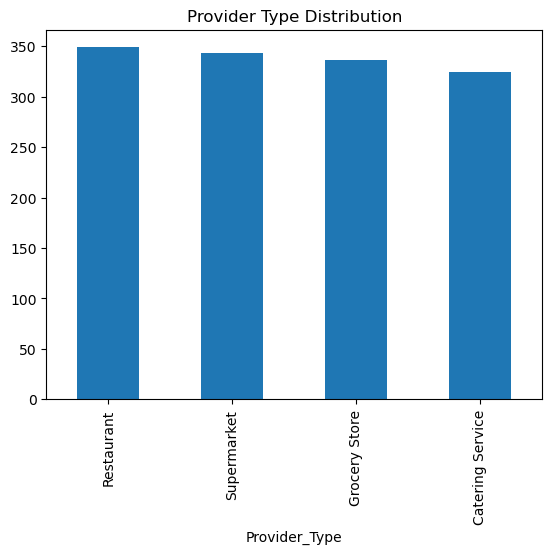

In [56]:
merged['Provider_Type'].value_counts().plot(kind='bar')
plt.title('Provider Type Distribution')
plt.show()

2. RECEIVER TYPE DISTRIBUTION

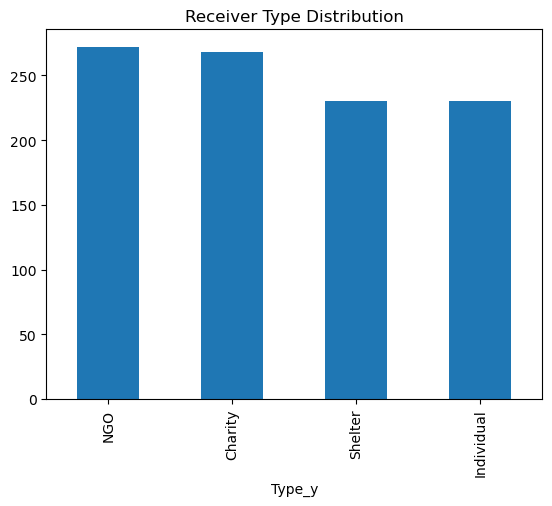

In [57]:
merged['Type_y'].value_counts().plot(kind='bar')
plt.title('Receiver Type Distribution')
plt.show()

3.FOOD TYPE DISTRIBUTION

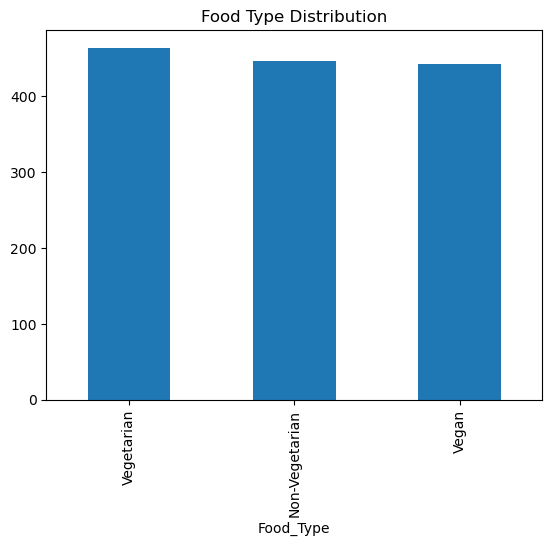

In [58]:
merged['Food_Type'].value_counts().plot(kind='bar')
plt.title('Food Type Distribution')
plt.show()

4. MEAL TYPE DISTRIBUTION

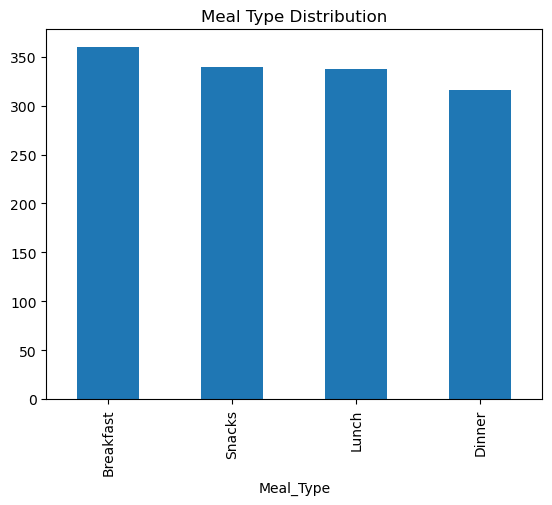

In [59]:
merged['Meal_Type'].value_counts().plot(kind='bar')
plt.title('Meal Type Distribution')
plt.show()

5.CITY VS FOOD LISTINGS

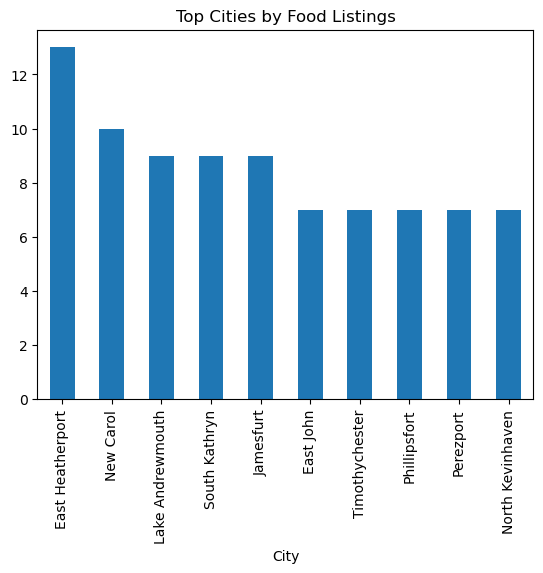

In [60]:
merged['City'].value_counts().head(10).plot(kind='bar')
plt.title('Top Cities by Food Listings')
plt.show()

6.PROVIDER TYPE VS QUANTITY

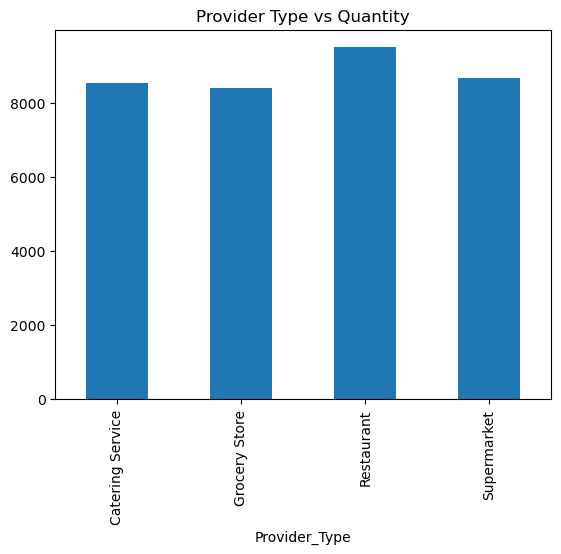

In [61]:
merged.groupby('Provider_Type')['Quantity'].sum().plot(kind='bar')
plt.title('Provider Type vs Quantity')
plt.show()

7. FOOD TYPE VS QUANTITY

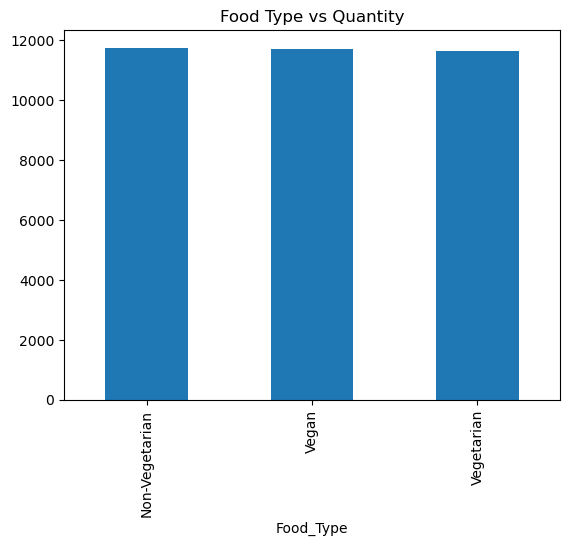

In [62]:
merged.groupby('Food_Type')['Quantity'].sum().plot(kind='bar')
plt.title('Food Type vs Quantity')
plt.show()

8. MEAL TYPE VS QUANTITY

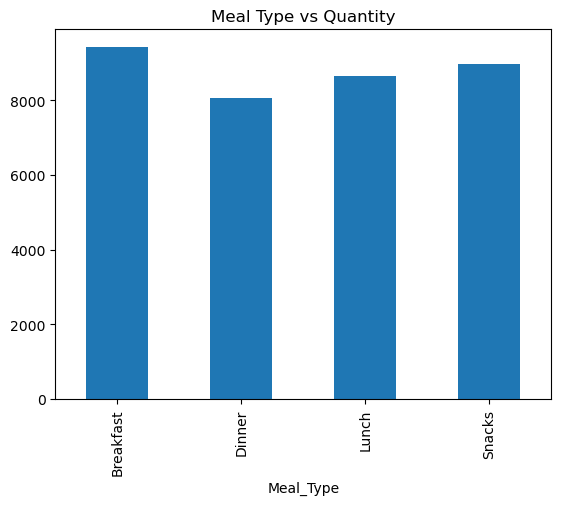

In [63]:
merged.groupby('Meal_Type')['Quantity'].sum().plot(kind='bar')
plt.title('Meal Type vs Quantity')
plt.show()

9. CITY + PROVIDER TYPE + QUANTITY

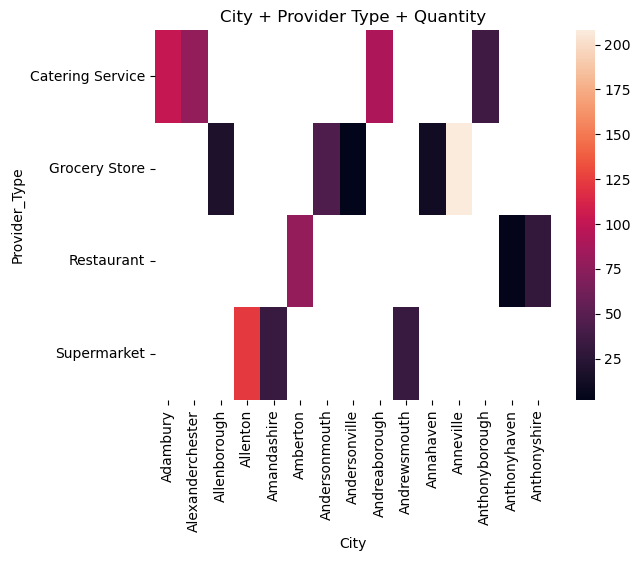

In [64]:
pivot = merged.pivot_table(
    values='Quantity',
    index='Provider_Type',
    columns='City',
    aggfunc='sum'
)

pivot = pivot.iloc[:, :15]   # sirf first/top cities

sns.heatmap(pivot)
plt.title('City + Provider Type + Quantity')
plt.show()

10. FOOD TYPE + MEAL TYPE + QUANTITY

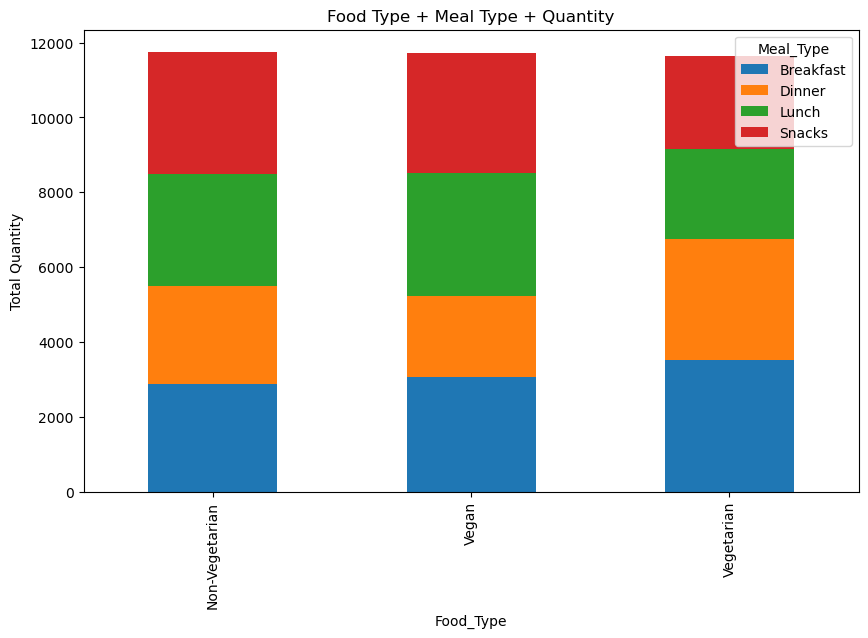

In [65]:
pivot = merged.pivot_table(
    values='Quantity',
    index='Food_Type',
    columns='Meal_Type',
    aggfunc='sum'
)

pivot.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.title('Food Type + Meal Type + Quantity')
plt.ylabel('Total Quantity')
plt.show()

11. PROVIDERS + CLAIMS + QUANTITY

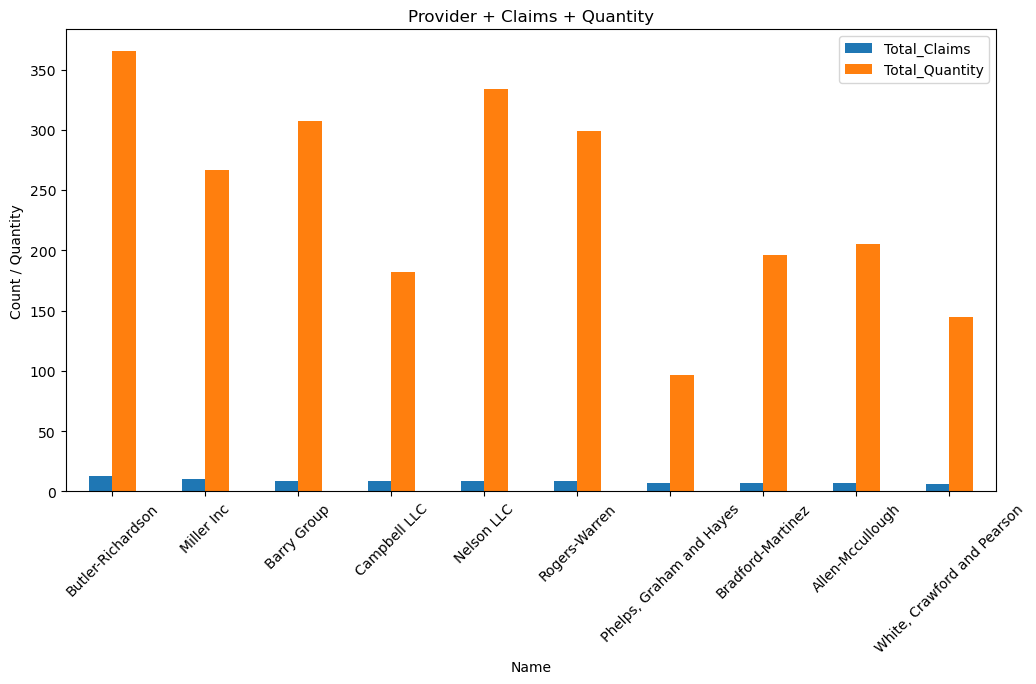

In [69]:
provider_analysis = merged.groupby('Name').agg(
    Total_Claims=('Food_ID','count'),
    Total_Quantity=('Quantity','sum')
)

top_providers = provider_analysis.sort_values(
    'Total_Claims',
    ascending=False
).head(10)

top_providers.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Provider + Claims + Quantity')
plt.ylabel('Count / Quantity')
plt.xticks(rotation=45)
plt.show()

12. RECEIVERS + CLAIMS + QUANTITY

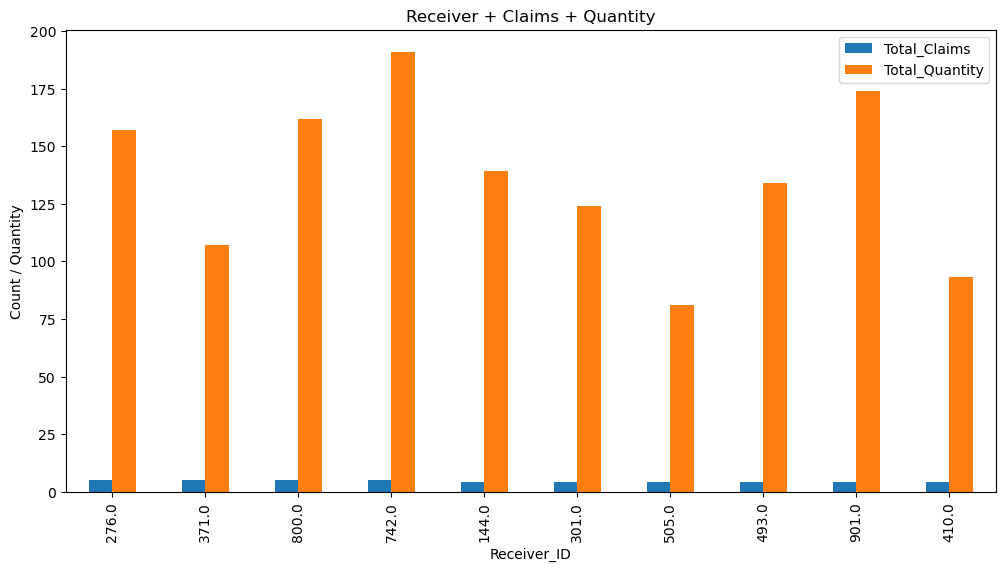

In [70]:
receiver_analysis = merged.groupby('Receiver_ID').agg(
    Total_Claims=('Food_ID','count'),
    Total_Quantity=('Quantity','sum')
)

top_receivers = receiver_analysis.sort_values(
    'Total_Claims',
    ascending=False
).head(10)

top_receivers.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Receiver + Claims + Quantity')
plt.ylabel('Count / Quantity')
plt.show()

13. CLAIM STATUS DISTRIBUTION

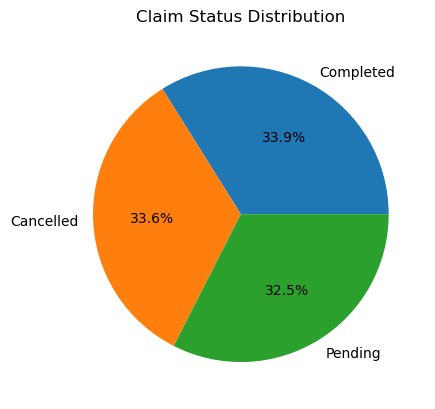

In [71]:
merged['Status'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Claim Status Distribution')
plt.ylabel('')
plt.show()

14. TOP RECEIVERS

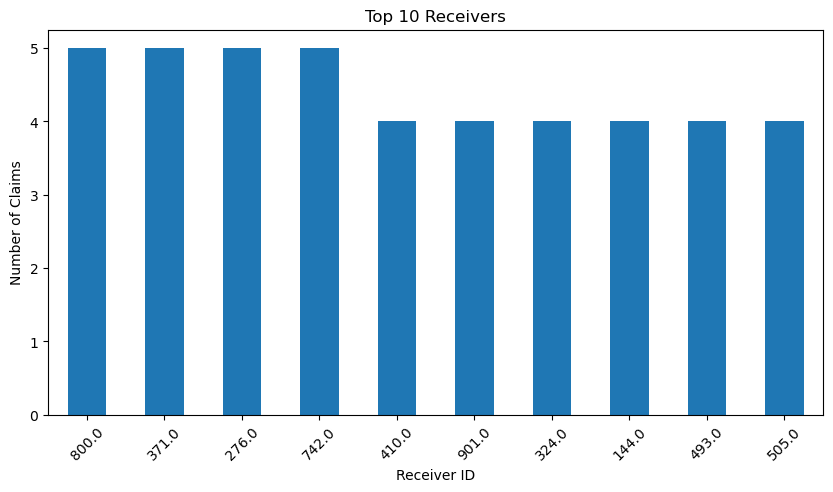

In [72]:
top_receivers = merged['Receiver_ID'].value_counts().head(10)

top_receivers.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Top 10 Receivers')
plt.xlabel('Receiver ID')
plt.ylabel('Number of Claims')
plt.xticks(rotation=45)
plt.show()

15. TOP PROVIDERS

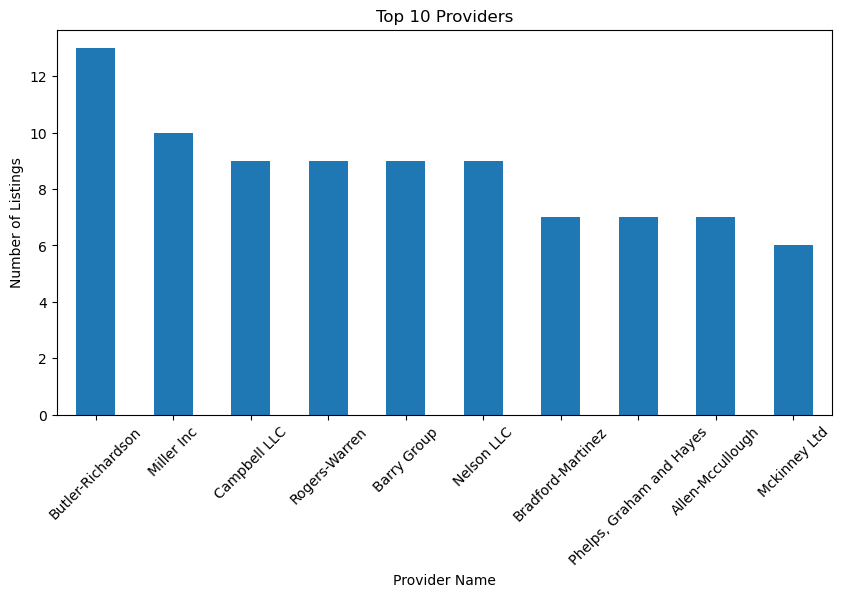

In [73]:
top_providers = merged['Name'].value_counts().head(10)

top_providers.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Top 10 Providers')
plt.xlabel('Provider Name')
plt.ylabel('Number of Listings')
plt.xticks(rotation=45)
plt.show()

In [74]:
food.to_csv("D:/food_cleaned.csv", index=False)


In [75]:
providers.to_csv("D:/providers_cleaned.csv", index=False)
receivers.to_csv("D:/receivers_cleaned.csv", index=False)
claims.to_csv("D:/claims_cleaned.csv", index=False)
merged.to_csv("D:/merged_data.csv", index=False)
